# TP4 — Exploration du corpus

Corpus : articles du journal *Le Soir* contenant le terme « cinema », en français, pour les années 1954 et 1955.

Le corpus a été extrait de CAMille et contient 890 résultats.

In [1461]:
from pathlib import Path

import pandas as pd


data_file = Path("../data/raw/camille_cinema_le_soir_1954_1955.xlsx")

df = pd.read_excel(data_file)

print("Nombre de documents :", len(df))
print("Nombre de colonnes :", len(df.columns))
print("Colonnes :", df.columns.tolist())

Nombre de documents : 890
Nombre de colonnes : 11
Colonnes : ['ID', 'JOURNAL', 'DATE', 'ANNÉE', 'MOIS', 'JOUR', 'JDLS', 'ÉDITION', 'PAGE', 'LANGUE', 'TEXTE']


## 1. Vérification du corpus

Je vérifie que le fichier exporté correspond bien au corpus défini dans CAMille : journal *Le Soir*, langue française, années 1954 et 1955.

In [1462]:
print("Journaux présents :")
print(df["JOURNAL"].value_counts())

print("\nLangues présentes :")
print(df["LANGUE"].value_counts())

print("\nDocuments par année :")
print(df["ANNÉE"].value_counts().sort_index())

print("\nTextes manquants :", df["TEXTE"].isna().sum())

Journaux présents :
JOURNAL
JB838    890
Name: count, dtype: int64

Langues présentes :
LANGUE
fr-BE    890
Name: count, dtype: int64

Documents par année :
ANNÉE
1954    403
1955    487
Name: count, dtype: int64

Textes manquants : 0


## 2. Doublons et longueur des textes

Je vérifie si certains documents ou certains textes apparaissent plusieurs fois, puis j'examine la longueur des textes issus de l'OCR.

In [1463]:
print("ID dupliqués :", df["ID"].duplicated().sum())
print("Textes dupliqués :", df["TEXTE"].duplicated().sum())

df["LONGUEUR"] = df["TEXTE"].str.len()

print("\nLongueur des textes :")
print(df["LONGUEUR"].describe())

ID dupliqués : 0
Textes dupliqués : 0

Longueur des textes :
count     890.000000
mean     2088.931461
std       707.819085
min       130.000000
25%      1891.000000
50%      1963.000000
75%      1997.000000
max      5918.000000
Name: LONGUEUR, dtype: float64


## 3. Inspection des textes

La distribution des longueurs est fortement concentrée autour de 2 000 caractères. On examine quelques textes courts, moyens et longs afin de comprendre ce que représente exactement le champ `TEXTE` dans l'export CAMille et d'observer la qualité de l'OCR.

In [1464]:
# Texte le plus court
shortest = df.loc[df["LONGUEUR"].idxmin()]

print("Texte le plus court")
print("ID :", shortest["ID"])
print("Date :", shortest["DATE"])
print("Page :", shortest["PAGE"])
print("Longueur :", shortest["LONGUEUR"])
print(shortest["TEXTE"])

Texte le plus court
ID : KB_JB838_1955-12-30_01-00011
Date : 1955-12-30 00:00:00
Page : 11
Longueur : 130
UitsnJctujî BEAUXARTS <kw>CINEMA</kw> D'ESSAI LW Uçmk de k l&iêi Hoüie PETER LE CHARBONNIER joure H£#z) V.O. fc A ffilililllllllll


In [1465]:
# Examiner quelques documents au hasard
sample = df.sample(5, random_state=42)

for _, row in sample.iterrows():
    print("=" * 80)
    print("ID :", row["ID"])
    print("Date :", row["DATE"])
    print("Page :", row["PAGE"])
    print("Longueur :", row["LONGUEUR"])
    print()
    print(row["TEXTE"])
    print()

ID : KB_JB838_1955-03-11_01-00015
Date : 1955-03-11 00:00:00
Page : 15
Longueur : 1986

Bonne rémunération assurée Ecrire Agence Rossel num. 79531H Ou demande CAISSIERE pour important <kw>CINEMA</kw> à Bruxelles Ecr. curr. vit.. prét.Ag.Rossel 79592H S) \**X**3s* VWiVJbX:- * PROSPECTEUR BILINGUE (français-flamand) est demandé pour visiter avec une camionnette tes clients particuliers et magasins clientèle préparée par £ forte publicité. Appointements fixes 2 4- lots sociales 4- bonnes commissions. Mise au courant par la Firme. Région à visiter : Brabant et début des Flandres. Nécessité habiter l’en- droit. Offres avec tous renseig.: âge, S études, réf. Agence Rossel 78466H 5 KXVÉWXS NVVWLSS* sxvvé STENO-DACTYLO expérimentée, français, flamand, anglais, est demandée par société très importante. Situation stable. Age maxim. 35 ans. Envoyer demande détaillée à l’Agence Rossel sous* n° 79J76H iNsruur dt PSYCHOLOGIE INDUSTRIELLE SOUffim CHARGES SELECTION : DEUX BONS EMPLOYES pour BRUXELLES 

### Première observation du corpus

L'examen manuel de quelques résultats montre que le corpus est hétérogène. Certains textes sont des critiques ou articles consacrés au cinéma, tandis que d'autres correspondent à des programmes de salles, des petites annonces ou des blocs OCR contenant du texte voisin sans rapport direct avec le cinéma.

La qualité de l'OCR varie également selon la mise en page. Les textes composés en colonnes, les annonces et les programmes présentent davantage d'erreurs de reconnaissance.

Les 890 résultats seront donc considérés comme des résultats de recherche CAMille contenant le terme « cinema », et non comme 890 articles exclusivement consacrés au cinéma.

In [1466]:
df["TEXTE_NETTOYE"] = (
    df["TEXTE"]
    .str.replace("<kw>", "", regex=False)
    .str.replace("</kw>", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["TEXTE", "TEXTE_NETTOYE"]].head()

,TEXTE,TEXTE_NETTOYE
0,"QMBQSSflDOR BOURSE Tel. 126,939 <kw>CINEMA</kw...","QMBQSSflDOR BOURSE Tel. 126,939 CINEMA NOVELTY..."
1,f 10 LB sont VENDREDI H MAI 1954 - *' * » n * ...,f 10 LB sont VENDREDI H MAI 1954 - *' * » n * ...
2,GALERIES CHARLES LAUGHTON JOHN MILLS et BRENDA...,GALERIES CHARLES LAUGHTON JOHN MILLS et BRENDA...
3,: \ 74123 ■' Vendredi 21 .janvier1955 - d'Alex...,: \ 74123 ■' Vendredi 21 .janvier1955 - d'Alex...
4,JOHN GREGSON * DINAH SHERIDAN GALERIES galerie...,JOHN GREGSON * DINAH SHERIDAN GALERIES galerie...


## 4. Première analyse de fréquence

Je tokenise les textes nettoyés et j'observe les mots les plus fréquents avant d'enrichir la liste de stopwords.

In [1467]:
import re
from collections import Counter


text = " ".join(df["TEXTE_NETTOYE"]).lower()

tokens = re.findall(r"\b[a-zàâçéèêëîïôûùüÿœæ'-]+\b", text)

frequencies = Counter(tokens)

frequencies.most_common(50)

[('de', 9449),
 ('a', 6039),
 ('à', 4895),
 ('et', 4737),
 ('la', 3890),
 ('le', 3397),
 ('l', 2694),
 ('n', 2456),
 ('d', 2373),
 ('e', 2292),
 ('r', 2256),
 ('du', 2237),
 ('rossel', 2166),
 ('les', 2141),
 ('ag', 1970),
 ('tél', 1968),
 ('en', 1882),
 ('des', 1825),
 ('p', 1800),
 ('dem', 1714),
 ('f', 1706),
 ('h', 1701),
 ('s', 1655),
 ('rue', 1638),
 ('pour', 1534),
 ('au', 1499),
 ('v', 1466),
 ('i', 1426),
 ('t', 1381),
 ('un', 1365),
 ('m', 1335),
 ('fr', 1334),
 ('ec', 1180),
 ('ou', 1141),
 ('pr', 1100),
 ('cinema', 1041),
 ('une', 1030),
 ('avec', 980),
 ('par', 972),
 ('dans', 947),
 ('j', 947),
 ('b', 945),
 ('est', 930),
 ('se', 891),
 ('bruxelles', 886),
 ('ch', 873),
 ('av', 845),
 ('on', 830),
 ('que', 770),
 ('c', 709)]

In [1468]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("french"))

tokens_filtered = [
    token
    for token in tokens
    if token not in stop_words
    and len(token) > 1
]

frequencies_filtered = Counter(tokens_filtered)

frequencies_filtered.most_common(50)

[nltk_data] Downloading package stopwords to /home/rhoun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('rossel', 2166),
 ('ag', 1970),
 ('tél', 1968),
 ('dem', 1714),
 ('rue', 1638),
 ('fr', 1334),
 ('ec', 1180),
 ('pr', 1100),
 ('cinema', 1041),
 ('bruxelles', 886),
 ('ch', 873),
 ('av', 845),
 ('ecrire', 618),
 ('ecr', 618),
 ('ea', 612),
 ('bon', 588),
 ('plus', 540),
 ('rem', 538),
 ('pf', 515),
 ('prix', 479),
 ('brux', 475),
 ('ans', 472),
 ('ena', 458),
 ('demande', 443),
 ('prés', 443),
 ('bien', 396),
 ('tout', 368),
 ('très', 368),
 ('enf', 361),
 ('maison', 357),
 ('tous', 345),
 ('sans', 340),
 ('agence', 335),
 ('pl', 328),
 ('do', 327),
 ('film', 326),
 ('si', 319),
 ('bd', 293),
 ('grand', 284),
 ('trav', 276),
 ('soir', 268),
 ('avenue', 261),
 ('libre', 260),
 ('cinéma', 258),
 ('remettre', 256),
 ('place', 255),
 ('cause', 252),
 ('admis', 248),
 ('comm', 242),
 ('café', 239)]

In [1469]:
custom_stopwords = {
    # Terme de la requête
    "cinema",
    "cinéma",

    # Petites annonces / mentions récurrentes du journal
    "rossel",
    "ag",
    "agence",
    "tél",
    "dem",
    "ecrire",
    "ecr",

    # Abréviations et bruit OCR très fréquents
    "fr",
    "ec",
    "pr",
    "ch",
    "av",
    "ea",
    "rem",
    "pf",
    "ena",
    "enf",
    "brux",
    "bd",
    "trav",
    "comm",

    # Nom du journal
    "soir",
}

stop_words.update(custom_stopwords)

tokens_filtered = [
    token
    for token in tokens
    if token not in stop_words
    and len(token) > 1
]

frequencies_filtered = Counter(tokens_filtered)

frequencies_filtered.most_common(50)

[('rue', 1638),
 ('bruxelles', 886),
 ('bon', 588),
 ('plus', 540),
 ('prix', 479),
 ('ans', 472),
 ('demande', 443),
 ('prés', 443),
 ('bien', 396),
 ('tout', 368),
 ('très', 368),
 ('maison', 357),
 ('tous', 345),
 ('sans', 340),
 ('pl', 328),
 ('do', 327),
 ('film', 326),
 ('si', 319),
 ('grand', 284),
 ('avenue', 261),
 ('libre', 260),
 ('remettre', 256),
 ('place', 255),
 ('cause', 252),
 ('admis', 248),
 ('café', 239),
 ('enfants', 238),
 ('centre', 237),
 ('tr', 229),
 ('bonne', 228),
 ('adm', 224),
 ('cherche', 222),
 ('louer', 220),
 ('belle', 219),
 ('non', 218),
 ('téléph', 217),
 ('heures', 216),
 ('pet', 216),
 ('tech', 214),
 ('etc', 208),
 ('beau', 207),
 ('vente', 206),
 ('vendredi', 203),
 ('techn', 200),
 ('sous', 200),
 ('xl', 199),
 ('van', 197),
 ('mod', 196),
 ('bail', 195),
 ('gros', 192)]

In [1470]:
custom_stopwords_2 = {
    # Adresses et petites annonces
    "rue",
    "avenue",
    "téléph",
    "demande",
    "cherche",
    "louer",
    "vente",
    "bail",
    "maison",
    "remettre",

    # Abréviations / bruit OCR
    "pl",
    "do",
    "tr",
    "adm",
    "pet",
    "mod",
    "xl",

    # Termes peu informatifs
    "bon",
    "bonne",
    "plus",
    "bien",
    "tout",
    "tous",
    "très",
    "sans",
    "si",
    "cause",
    "vendredi",
}

stop_words.update(custom_stopwords_2)

tokens_filtered = [
    token
    for token in tokens
    if token not in stop_words
    and len(token) > 1
]

frequencies_filtered = Counter(tokens_filtered)

frequencies_filtered.most_common(50)

[('bruxelles', 886),
 ('prix', 479),
 ('ans', 472),
 ('prés', 443),
 ('film', 326),
 ('grand', 284),
 ('libre', 260),
 ('place', 255),
 ('admis', 248),
 ('café', 239),
 ('enfants', 238),
 ('centre', 237),
 ('belle', 219),
 ('non', 218),
 ('heures', 216),
 ('tech', 214),
 ('etc', 208),
 ('beau', 207),
 ('techn', 200),
 ('sous', 200),
 ('van', 197),
 ('gros', 192),
 ('femme', 190),
 ('après', 188),
 ('mois', 187),
 ('deux', 186),
 ('français', 185),
 ('vendre', 183),
 ('neuve', 178),
 ('an', 176),
 ('faire', 176),
 ('gar', 176),
 ('reprise', 174),
 ('serveuse', 166),
 ('films', 165),
 ('offre', 164),
 ('mm', 162),
 ('loyer', 162),
 ('grande', 161),
 ('gr', 160),
 ('jean', 158),
 ('ét', 158),
 ('cette', 157),
 ('tel', 156),
 ('magasin', 156),
 ('jour', 155),
 ('francs', 155),
 ('jeudi', 153),
 ('travail', 152),
 ('entre', 152)]

In [1471]:
custom_stopwords_3 = {
    # Contexte géographique déjà imposé par le corpus
    "bruxelles",

    # Vocabulaire générique / peu discriminant
    "ans",
    "prés",
    "grand",
    "libre",
    "place",
    "heures",
    "non",
    "sous",
    "gros",
    "après",
    "mois",
    "deux",
    "an",
    "faire",
    "grande",
    "cette",
    "jour",
    "entre",

    # Petites annonces
    "café",
    "vendre",
    "neuve",
    "serveuse",
    "offre",
    "loyer",
    "magasin",
    "francs",
    "travail",

    # Abréviations / bruit OCR
    "gar",
    "mm",
    "gr",
    "ét",
    "tel",
}

stop_words.update(custom_stopwords_3)

tokens_filtered = [
    token
    for token in tokens
    if token not in stop_words
    and len(token) > 1
]

frequencies_filtered = Counter(tokens_filtered)

frequencies_filtered.most_common(50)

[('prix', 479),
 ('film', 326),
 ('admis', 248),
 ('enfants', 238),
 ('centre', 237),
 ('belle', 219),
 ('tech', 214),
 ('etc', 208),
 ('beau', 207),
 ('techn', 200),
 ('van', 197),
 ('femme', 190),
 ('français', 185),
 ('reprise', 174),
 ('films', 165),
 ('jean', 158),
 ('jeudi', 153),
 ('midi', 151),
 ('jeune', 151),
 ('com', 150),
 ('présenter', 149),
 ('commerce', 149),
 ('salle', 148),
 ('réf', 148),
 ('santé', 148),
 ('mat', 147),
 ('neuf', 147),
 ('paris', 146),
 ('samedi', 145),
 ('anvers', 145),
 ('sit', 142),
 ('bel', 142),
 ('comme', 141),
 ('bourse', 139),
 ('mol', 139),
 ('mag', 138),
 ('num', 136),
 ('cafe', 136),
 ('vie', 135),
 ('jours', 134),
 ('semaine', 134),
 ('cour', 133),
 ('garage', 133),
 ('dames', 133),
 ('technicolor', 132),
 ('br', 132),
 ('service', 131),
 ('part', 131),
 ('art', 131),
 ('téléphone', 130)]

## 5. Nuage de mots

À partir des fréquences filtrées, on génère un nuage de mots afin de visualiser les termes les plus présents dans le corpus.

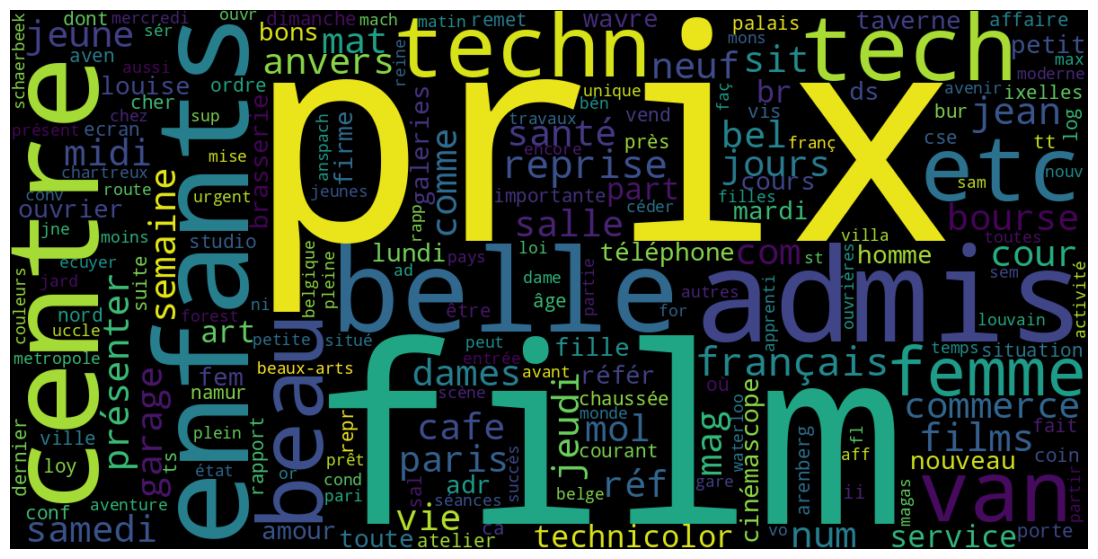

In [1472]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


wordcloud = WordCloud(
    width=1200,
    height=600,
    collocations=False
).generate_from_frequencies(frequencies_filtered)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 6. Reconnaissance d'entités nommées

Je cherche maintenant les principales personnes, organisations et lieux mentionnés dans le corpus.

In [1473]:
from collections import defaultdict
import spacy
from spacy.lang.fr.examples import sentences

In [1474]:
nlp = spacy.load("fr_core_news_md")

# Préparer le texte du corpus
n = 1_000_000
text = " ".join(df["TEXTE_NETTOYE"])[:n]

# Appliquer SpaCy
doc = nlp(text)

print("Nombre de caractères analysés :", len(text))
print("Nombre d'entités détectées :", len(doc.ents))

# Afficher les 30 premières entités reconnues
for ent in list(doc.ents)[:30]:
    print(ent.text, "->", ent.label_)

Nombre de caractères analysés : 1000000
Nombre d'entités détectées : 31939
QMBQSSflDOR BOURSE -> MISC
CINEMA NOVELTY -> ORG
CHAUSSEE DE -> MISC
WAVRE -> MISC
PRADO ETTERBEEK || MOLENBEEK DU -> MISC
SEPXEIVIBRE -> MISC
Cinémascope -> MISC
Cinéma : LA TUNIQUE PARLANT FRANÇAIS -> MISC
ENFANTS -> MISC
ADMIS -> MISC
TECHNICOLOR -> MISC
Victor MATURE -> PER
Jean SIMMONS -> PER
Ecran Miroir-Miracle -> MISC
T7tm<''sv -> MISC
JUIN U -> MISC
TM/’YirPTtv -> LOC
I -> LOC
h. Dimanche -> MISC
YVONNE SANS0N -> PER
NERON -> PER
VENDREDI 3 -> MISC
VALSE DE -> MISC
Un filin p& •• -> MISC
.,•✓ LEWIS MILESTOME -> MISC
MORLEY WJiWv MARITA -> MISC
iHH -> MISC
NARMI -> ORG
ACROPOLE -> MISC
Chaplin -> PER


In [1475]:
people = defaultdict(int)

for ent in doc.ents:
    if ent.label_ == "PER" and len(ent.text) > 3:
        people[ent.text] += 1

sorted_people = sorted(
    people.items(),
    key=lambda kv: kv[1],
    reverse=True
)

for person, freq in sorted_people[:50]:
    print(f"{person} apparait {freq} fois dans le corpus")

Rossel apparait 397 fois dans le corpus
Ecrire Ag apparait 54 fois dans le corpus
P. F. apparait 36 fois dans le corpus
- Tél apparait 30 fois dans le corpus
Tech apparait 24 fois dans le corpus
Inut apparait 23 fois dans le corpus
Agence Rossel apparait 22 fois dans le corpus
P.F. Enf apparait 20 fois dans le corpus
Jean Renoir apparait 18 fois dans le corpus
Walt Disney apparait 17 fois dans le corpus
Chaplin apparait 16 fois dans le corpus
trav apparait 15 fois dans le corpus
Louise apparait 15 fois dans le corpus
Fernandel apparait 14 fois dans le corpus
Continental apparait 14 fois dans le corpus
atel apparait 14 fois dans le corpus
E. A. apparait 13 fois dans le corpus
E. N. A. apparait 13 fois dans le corpus
LUXOR apparait 13 fois dans le corpus
Bonne apparait 13 fois dans le corpus
Rossel num apparait 13 fois dans le corpus
Gros apparait 13 fois dans le corpus
Maria Schell apparait 12 fois dans le corpus
curric apparait 12 fois dans le corpus
curr apparait 12 fois dans le corpu

In [1476]:
locations = defaultdict(int)

for ent in doc.ents:
    if ent.label_ == "LOC" and len(ent.text) > 3:
        locations[ent.text] += 1

sorted_locations = sorted(
    locations.items(),
    key=lambda kv: kv[1],
    reverse=True
)

for location, freq in sorted_locations[:50]:
    print(f"{location} apparait {freq} fois dans le corpus")

Bruxelles apparait 263 fois dans le corpus
Brux apparait 110 fois dans le corpus
Téléph apparait 83 fois dans le corpus
Wavre apparait 55 fois dans le corpus
Paris apparait 46 fois dans le corpus
Ixelles apparait 45 fois dans le corpus
Neuve apparait 41 fois dans le corpus
Belgique apparait 32 fois dans le corpus
Agence Rossel apparait 28 fois dans le corpus
Anvers apparait 26 fois dans le corpus
Bd Anspach apparait 24 fois dans le corpus
Laeken apparait 23 fois dans le corpus
rue Royale apparait 23 fois dans le corpus
Venise apparait 20 fois dans le corpus
rue Neuve apparait 20 fois dans le corpus
Anderlecht apparait 20 fois dans le corpus
BRUXELLES apparait 20 fois dans le corpus
Schaerbeek apparait 20 fois dans le corpus
Amour apparait 19 fois dans le corpus
Molenbeek apparait 19 fois dans le corpus
Gand apparait 19 fois dans le corpus
Tech apparait 18 fois dans le corpus
Louvain apparait 18 fois dans le corpus
Liège apparait 18 fois dans le corpus
Forest apparait 17 fois dans le co

In [1477]:
organizations = defaultdict(int)

for ent in doc.ents:
    if ent.label_ == "ORG" and len(ent.text) > 3:
        organizations[ent.text] += 1

sorted_organizations = sorted(
    organizations.items(),
    key=lambda kv: kv[1],
    reverse=True
)

for organization, freq in sorted_organizations[:50]:
    print(f"{organization} apparait {freq} fois dans le corpus")

Techn apparait 71 fois dans le corpus
GALERIES apparait 30 fois dans le corpus
PF EA apparait 29 fois dans le corpus
ARENBERG apparait 27 fois dans le corpus
LEOPOLD apparait 25 fois dans le corpus
ELDO apparait 23 fois dans le corpus
CENTRA apparait 23 fois dans le corpus
CINEMA dem apparait 23 fois dans le corpus
Technic apparait 22 fois dans le corpus
AVIA apparait 21 fois dans le corpus
FRANÇAIS apparait 21 fois dans le corpus
Agence Rossel num apparait 20 fois dans le corpus
AVENTURE apparait 18 fois dans le corpus
Agence Rossel apparait 18 fois dans le corpus
CITY apparait 16 fois dans le corpus
ELYSEE apparait 16 fois dans le corpus
DIXY apparait 16 fois dans le corpus
FILMAC apparait 15 fois dans le corpus
pf ea apparait 15 fois dans le corpus
Inst apparait 15 fois dans le corpus
Pain apparait 14 fois dans le corpus
Téléphone apparait 14 fois dans le corpus
BRAZIL apparait 13 fois dans le corpus
FIRME apparait 13 fois dans le corpus
HELMET apparait 13 fois dans le corpus
trav a

### Observation sur la reconnaissance d'entités

La reconnaissance d'entités nommées fonctionne partiellement sur le corpus. Les lieux sont globalement mieux identifiés que les personnes et les organisations. Les erreurs d'OCR et la mise en page des annonces provoquent de nombreux faux positifs.

Parmi les personnes détectées figurent notamment Jean Renoir, Walt Disney, Chaplin, Fernandel, Maria Schell, Humphrey Bogart et James Stewart. Les lieux comprennent Bruxelles, Paris, Anvers, Gand, Liège, Namur, Hollywood et le Congo. Pour les organisations, plusieurs noms de salles de cinéma apparaissent, mais la catégorie contient également beaucoup de bruit OCR.

Ces résultats doivent donc être interprétés après vérification dans les textes.

In [1478]:
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer

tb = Blobber(
    pos_tagger=PatternTagger(),
    analyzer=PatternAnalyzer()
)

def get_sentiment(input_text):
    blob = tb(input_text)

    polarity, subjectivity = blob.sentiment

    polarity_perc = f"{100 * abs(polarity):.0f}"
    subjectivity_perc = f"{100 * subjectivity:.0f}"

    if polarity > 0:
        polarity_str = f"{polarity_perc}% positive"
    elif polarity < 0:
        polarity_str = f"{polarity_perc}% negative"
    else:
        polarity_str = "neutral"

    if subjectivity > 0:
        subjectivity_str = f"{subjectivity_perc}% subjective"
    else:
        subjectivity_str = "perfectly objective"

    print(f"This text is {polarity_str} and {subjectivity_str}.")


get_sentiment("Ce journal est vraiment super intéressant.")

This text is 65% positive and 75% subjective.


In [1479]:
def sentiment_values(input_text):
    blob = tb(input_text)
    polarity, subjectivity = blob.sentiment

    return polarity, subjectivity


polarity, subjectivity = sentiment_values(
    "Ce journal est vraiment super intéressant."
)

print("Polarité :", polarity)
print("Subjectivité :", subjectivity)

Polarité : 0.65
Subjectivité : 0.75


In [1480]:
sample = df.sample(10, random_state=42)

sentences_sample = []

for text in sample["TEXTE_NETTOYE"]:
    doc_sample = nlp(text)

    for sentence in doc_sample.sents:
        sentence_text = sentence.text.strip()

        if len(sentence_text) > 50:
            sentences_sample.append(sentence_text)
            break

for i, sentence in enumerate(sentences_sample, 1):
    print(f"{i}. {sentence}\n")

1. Bonne rémunération assurée Ecrire Agence Rossel num.

2. IL L,A;~ r -t,j Le chef des bandits (MILTON RIBIERO) diçto au traître par amour (ALBERTO ItUSCIIEL) la façon dont il va mourir.

3. -E.N.A. 81089 DE FELLINI lauleur de"LA STRADA CINEMA D'ESSAI

4. Si quelqu'un m'avait demandé, avant que j’aie lu le livre que vient de lui consacrer Jean Mitry (a.nx Editions Universitaires), ce que je pensais de John Ford, je n’aurais pas hésité à répondre :

5. ★ VOTRE CARACTERE PAR VOTRE ECRITURE Khrouchtchev, premier secrétaire du parti communiste soviétique, affirmait au dixième congrès du parti communiste tchécoslovaque, à Prague, que « l’Union soviétique avait été la première nation à posséder la bombe H ».

6. Pendant que les époux Hagon- Mathirin cour Mondez, à Frasnes- lez-Gosselies, étaient au cinéma, des voleurs se sont introduits par effraction dans leur domicile en brisant une Vitre.

7. $ CINEMA à vendre ou à louer en pleine activité, situe commune importante

8. 6373N Plantation c

In [1481]:
results = []

for sentence in sentences_sample:
    polarity, subjectivity = sentiment_values(sentence)

    results.append({
        "Phrase": sentence,
        "Polarité": polarity,
        "Subjectivité": subjectivity
    })

sentiment_df = pd.DataFrame(results)

sentiment_df

,Phrase,Polarité,Subjectivité
0,Bonne rémunération assurée Ecrire Agence Rosse...,0.450000,0.450000
1,"IL L,A;~ r -t,j Le chef des bandits (MILTON RI...",0.000000,0.000000
2,"-E.N.A. 81089 DE FELLINI lauleur de""LA STRADA ...",-0.050000,0.000000
3,"Si quelqu'un m'avait demandé, avant que j’aie ...",0.100000,0.600000
4,★ VOTRE CARACTERE PAR VOTRE ECRITURE Khrouchtc...,-0.012500,0.125000
5,Pendant que les époux Hagon- Mathirin cour Mon...,0.000000,0.000000
6,$ CINEMA à vendre ou à louer en pleine activit...,0.256667,0.283333
7,6373N Plantation ca/é A vendre région Stan- lc...,0.000000,0.000000
8,55139m Pouvons utiliser capitaux intérêt fixe ...,0.100000,0.066667
9,"Alétciuik Dans un virage, la roue arrière inté...",0.094000,0.072000


### Interprétation des résultats

Les résultats montrent que l'analyse de sentiment fonctionne de manière inégale sur ce corpus.

Plusieurs phrases obtiennent une polarité nulle ou très proche de zéro. C'est notamment le cas des phrases descriptives ou factuelles, mais aussi de textes fortement bruités par l'OCR.

La première phrase obtient une polarité positive de 0,45, probablement en raison de l'expression « Bonne rémunération assurée ». La phrase consacrée à John Ford est légèrement positive (0,10) mais relativement subjective (0,60), ce qui correspond davantage à un texte critique exprimant un jugement.

Certaines limites de la méthode apparaissent clairement. La phrase décrivant un cambriolage obtient une polarité et une subjectivité nulles, alors que son contenu décrit un événement négatif. À l'inverse, l'annonce « CINEMA à vendre ou à louer en pleine activité » obtient une polarité positive de 0,26, probablement à cause de l'expression « pleine activité ».

Les erreurs d'OCR influencent également l'analyse. Certaines phrases contiennent des fragments mal reconnus ou des mots incomplets, ce qui réduit la capacité de TextBlob-FR à identifier correctement leur polarité.

L'analyse de sentiment doit donc être interprétée avec prudence sur ce corpus de presse historique. Les scores automatiques donnent des indications, mais ils doivent être confrontés à une lecture humaine des textes.

## 7. Clustering des documents

On applique un clustering K-Means aux 890 résultats du corpus. Les documents sont d'abord représentés sous forme de vecteurs TF-IDF, selon la méthode utilisée dans `s2_clustering.ipynb`.

In [1482]:
# Identifiants et textes des documents
files = df["ID"].tolist()
texts = df["TEXTE_NETTOYE"].tolist()

print("Nombre de documents :", len(texts))
print("Premier document :", files[0])
print()
print(texts[0][:400])

Nombre de documents : 890
Premier document : KB_JB838_1954-09-03_01-00010

QMBQSSflDOR BOURSE Tel. 126,939 CINEMA NOVELTY CINEMA KINOX 20. 852, CHAUSSEE DE WAVRE 20, RUE DU PRADO ETTERBEEK || MOLENBEEK DU 3 AU 9 SEPXEIVIBRE Le grand film en Cinémascope, lo perfectionnement du Cinéma : LA TUNIQUE PARLANT FRANÇAIS — ENFANTS ADMIS — TECHNICOLOR avec Victor MATURE et Jean SIMMONS présenté, et sans lunettes, sur nouvel Ecran Miroir-Miracle avec son stéréophonique dans des sal


In [1483]:
import nltk

nltk.download("punkt_tab")

def preprocessing(text, stem=True):
    """Tokenize text and remove punctuation."""
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text, language="french")
    return tokens

[nltk_data] Downloading package punkt_tab to /home/rhoun/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [1484]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(
    tokenizer=preprocessing,
    token_pattern=None,
    stop_words=stopwords.words("french"),
    max_df=0.5,
    min_df=0.1,
    lowercase=True,
)

tfidf_vectors = vectorizer.fit_transform(texts)

print("Dimensions de la matrice TF-IDF :", tfidf_vectors.shape)
print("Nombre de termes retenus :", len(vectorizer.get_feature_names_out()))

Dimensions de la matrice TF-IDF : (890, 216)
Nombre de termes retenus : 216


In [1485]:
pd.Series(
    tfidf_vectors[0].toarray()[0],
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

e        0.470129
tech     0.357505
•        0.337611
p        0.321423
■        0.217262
           ...   
ville    0.000000
‘        0.000000
être     0.000000
ét       0.000000
âge      0.000000
Length: 216, dtype: float64

In [1486]:
def preprocessing(text, stem=True):
    """Tokenize text and remove punctuation and OCR noise."""
    tokens = word_tokenize(text.lower(), language="french")

    tokens = [
        token
        for token in tokens
        if token.isalpha()
        and len(token) > 1
    ]

    return tokens

In [1487]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocessing,
    token_pattern=None,
    stop_words=list(stop_words),
    max_df=0.5,
    min_df=0.1,
    lowercase=True,
)

tfidf_vectors = vectorizer.fit_transform(texts)

print("Dimensions de la matrice TF-IDF :", tfidf_vectors.shape)
print("Nombre de termes retenus :", len(vectorizer.get_feature_names_out()))

Dimensions de la matrice TF-IDF : (890, 84)
Nombre de termes retenus : 84


In [1488]:
pd.Series(
    tfidf_vectors[0].toarray()[0],
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False).head(20)

tech        0.802094
wavre       0.263159
jours       0.258380
jean        0.250275
film        0.204932
ecran       0.133253
samedi      0.125845
jeudi       0.124788
salle       0.124441
français    0.116604
admis       0.115756
van         0.112527
enfants     0.108112
art         0.000000
aven        0.000000
beau        0.000000
arenberg    0.000000
adr         0.000000
affaire     0.000000
anvers      0.000000
dtype: float64

In [1489]:
from scipy.spatial.distance import cosine


print(cosine([1, 2, 3], [1, 2, 3]))
print(cosine([1, 2, 3], [1, 2, 2]))
print(cosine([1, 2, 3], [2, 2, 2]))

0.0
0.02004211298777725
0.07417990022744858


In [1490]:
from scipy.spatial.distance import cosine


doc_1 = tfidf_vectors[0].toarray()[0]
doc_2 = tfidf_vectors[1].toarray()[0]
doc_3 = tfidf_vectors[2].toarray()[0]

print("Distance document 1 / document 2 :", cosine(doc_1, doc_2))
print("Distance document 1 / document 3 :", cosine(doc_1, doc_3))
print("Distance document 2 / document 3 :", cosine(doc_2, doc_3))

Distance document 1 / document 2 : 0.8608852312912778
Distance document 1 / document 3 : 0.6670132373506995
Distance document 2 / document 3 : 0.29448489138981915


In [1491]:
import collections
from pprint import pprint
from sklearn.cluster import KMeans

N_CLUSTERS = 5

km_model = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42
)

clusters = km_model.fit_predict(tfidf_vectors)

pd.Series(clusters).value_counts().sort_index()

0    242
1    204
2    161
3    119
4    164
Name: count, dtype: int64

In [1492]:
terms = vectorizer.get_feature_names_out()
order_centroids = km_model.cluster_centers_.argsort()[:, ::-1]

for cluster_id in range(N_CLUSTERS):
    print(f"\nCluster {cluster_id} ({sum(clusters == cluster_id)} documents)")
    
    top_terms = [
        terms[index]
        for index in order_centroids[cluster_id, :15]
    ]
    
    print(", ".join(top_terms))


Cluster 0 (242 documents)
film, comme, films, dont, fait, être, jean, mardi, jeudi, vie, suite, samedi, nouveau, français, part

Cluster 1 (204 documents)
présenter, firme, bons, réf, jeune, service, dames, âge, num, cour, anvers, van, femme, cher, ts

Cluster 2 (161 documents)
reprise, santé, beau, centre, cafe, sit, garage, bel, com, prix, commerce, affaire, unique, belle, ds

Cluster 3 (119 documents)
prix, neuf, br, part, van, ts, toutes, anvers, bel, midi, aven, salle, fait, films, téléphone

Cluster 4 (164 documents)
admis, tech, techn, enfants, film, ecran, galeries, français, studio, arenberg, paris, jean, dernier, belle, homme


In [1493]:
# Ajouter le numéro de cluster au DataFrame
df["CLUSTER"] = clusters

# Afficher 3 documents de chaque cluster
for cluster_id in range(N_CLUSTERS):
    print("=" * 100)
    print(f"CLUSTER {cluster_id}")
    print("=" * 100)

    sample_cluster = df[df["CLUSTER"] == cluster_id].sample(
        3,
        random_state=42
    )

    for _, row in sample_cluster.iterrows():
        print("\nID :", row["ID"])
        print("Date :", row["DATE"])
        print("Page :", row["PAGE"])
        print()
        print(row["TEXTE_NETTOYE"][:800])
        print("-" * 100)

CLUSTER 0

ID : KB_JB838_1955-07-16_01-00005
Date : 1955-07-16 00:00:00
Page : 5

. • DEVENIR DU CINEMA. — C'est le thème qu'a choisi la revge L'âge nou veau pour son numéro de juillet. On .y'trouve des articles d'Henri Agel, d'André Bazin, de Georges Charensol, d'Abôl Gance, de René Lalou, do Jean Bousselot, de Marcel Brion et do Louis Le. Sidanor. Ce recueil est d un grand intérêt documentaire et bibliographique. . . • DANTE A L'INDEX AU PAKISTAN. — Jugée oiiensanle pour les sentiments musuJmans, car elle présente le prophète Mahomet souitrant en enter, la première parlip de La Divine Comédie de Dante, « L'enfer », a été interdite par les, autorités do police pakistanaises. Les exemplaires sb trouvant èn librairie ont été saisis. • LES LIVflES.DE CESBRON. — D'Edith Thomas dans le dernier bulletin de la Guilde du Livre : « A côté de la littérature do la préciosité, do 
----------------------------------------------------------------------------------------------------

ID : KB_JB838_1

In [1494]:
samples = []

for cluster_id in range(N_CLUSTERS):
    sample_cluster = df[df["CLUSTER"] == cluster_id].sample(
        3,
        random_state=42
    )

    for _, row in sample_cluster.iterrows():
        samples.append({
            "Cluster": cluster_id,
            "Date": row["DATE"],
            "Page": row["PAGE"],
            "Extrait": row["TEXTE_NETTOYE"][:300]
        })

samples_df = pd.DataFrame(samples)

samples_df

,Cluster,Date,Page,Extrait
0,0,1955-07-16,5,. • DEVENIR DU CINEMA. — C'est le thème qu'a c...
1,0,1955-01-07,16,LE CINEMA Le vingt-cinquième anniversaire de M...
2,0,1955-02-03,3,DE CETTE SEMAINE PRESENTE s Avant un grand mar...
3,1,1954-12-28,12,"Rossel n. 64529A a"" CV.V.V.VV.VcV.VV.V.V.Vsg C..."
4,1,1955-05-14,18,"GROOTHUIS, 12, rue du Frontispice, entre 14 et..."
5,1,1954-08-15,13,Rossel 57319H STUDIO CINEMA Dem. J. H. sér. et...
6,2,1955-03-13,20,T. 11.69.92. 23437 Plateaux tourm CESSATION D'...
7,2,1955-05-06,19,. - Tél. 34.41.74. 179 N CINEMA mod. en pl. ac...
8,2,1954-08-01,16,. — Ecrire Agence Rossel num. 8040M CINEMA ch....
9,3,1954-08-19,9,T.43.18.12 pour visites. 10689C Far suite de d...


### Interprétation des clusters

Le clustering fait apparaître plusieurs types de contenus dans les résultats CAMille.

- **Cluster 0 — articles et contenus rédactionnels sur le cinéma**  
  Les exemples comprennent notamment des articles consacrés à Walt Disney, au devenir du cinéma et à l'actualité cinématographique.

- **Cluster 1 — petites annonces et offres d'emploi**  
  Les textes contiennent de nombreuses références à l'Agence Rossel, à des demandes de personnel, à des firmes et à des emplois.

- **Cluster 2 — annonces commerciales et cessions d'activités**  
  Ce cluster contient principalement des annonces de vente, de location ou de reprise de commerces, parmi lesquels des cinémas.

- **Cluster 3 — annonces concernant des établissements cinématographiques**  
  Les exemples comprennent notamment des cinémas à vendre, à remettre ou recherchés.

- **Cluster 4 — programmes et annonces de salles de cinéma**  
  Les textes présentent des salles, des films, des horaires, des indications comme « enfants admis » ainsi que des mentions techniques comme Technicolor.

Les cinq clusters sont globalement interprétables. Les clusters 2 et 3 restent toutefois proches et montrent que la séparation des petites annonces commerciales est moins nette.

In [1495]:
from pathlib import Path
from nltk.tokenize import sent_tokenize


output_file = Path("../data/sents.txt")

with output_file.open("w", encoding="utf-8") as f:
    for text in df["TEXTE_NETTOYE"]:
        sentences = sent_tokenize(text, language="french")

        for sentence in sentences:
            sentence = sentence.strip()

            if len(sentence.split()) >= 3:
                f.write(sentence + "\n")

print("Fichier créé :", output_file)

Fichier créé : ../data/sents.txt


In [1496]:
with open("../data/sents.txt", encoding="utf-8") as f:
    for _ in range(10):
        print(f.readline().strip())

QMBQSSflDOR BOURSE Tel.
126,939 CINEMA NOVELTY CINEMA KINOX 20.
852, CHAUSSEE DE WAVRE 20, RUE DU PRADO ETTERBEEK || MOLENBEEK DU 3 AU 9 SEPXEIVIBRE Le grand film en Cinémascope, lo perfectionnement du Cinéma : LA TUNIQUE PARLANT FRANÇAIS — ENFANTS ADMIS — TECHNICOLOR avec Victor MATURE et Jean SIMMONS présenté, et sans lunettes, sur nouvel Ecran Miroir-Miracle avec son stéréophonique dans des salles brillamment transformées et rfiodernisées.
79467/68 T7tm<''sv .
Tous les jours : séances permanentes à partir au JUIN U a: de 13 heures.
„„ TM/’YirPTtv .
Tous les jours séances permanentes à partir.
QU I .
de 15 h.
Dimanche et jeudi à partir de 13 h.


In [1497]:
from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode

In [1498]:
class MySentences(object):
    """Tokenize sentences."""

    def __init__(self, filename):
        self.filename = filename

    def __iter__(self):
        for line in open(
            self.filename,
            encoding="utf-8",
            errors="backslashreplace"
        ):
            tokens = [
                unidecode(w.lower())
                for w in wordpunct_tokenize(line)
            ]

            yield [
                token
                for token in tokens
                if token.isalpha()
                and len(token) > 1
            ]

In [1499]:
infile = "../data/sents.txt"
sentences = MySentences(infile)

In [1500]:
for i, sentence in enumerate(sentences):
    print(sentence[:30])

    if i == 4:
        break

['qmbqssfldor', 'bourse', 'tel']
['cinema', 'novelty', 'cinema', 'kinox']
['chaussee', 'de', 'wavre', 'rue', 'du', 'prado', 'etterbeek', 'molenbeek', 'du', 'au', 'sepxeivibre', 'le', 'grand', 'film', 'en', 'cinemascope', 'lo', 'perfectionnement', 'du', 'cinema', 'la', 'tunique', 'parlant', 'francais', 'enfants', 'admis', 'technicolor', 'avec', 'victor', 'mature']
['sv']
['tous', 'les', 'jours', 'seances', 'permanentes', 'partir', 'au', 'juin', 'de', 'heures']


In [1501]:
bigram_phrases = Phrases(sentences)

print("Nombre d'éléments dans le vocabulaire :", len(bigram_phrases.vocab))

Nombre d'éléments dans le vocabulaire : 152025


In [1502]:
bigram = Phraser(bigram_phrases)

sentences_bigram = bigram[sentences]

In [1503]:
for i, sentence in enumerate(sentences_bigram):
    print(sentence[:30])

    if i == 4:
        break

['qmbqssfldor', 'bourse', 'tel']
['cinema', 'novelty', 'cinema', 'kinox']
['chaussee', 'de', 'wavre', 'rue_du', 'prado', 'etterbeek', 'molenbeek', 'du', 'au', 'sepxeivibre', 'le', 'grand_film', 'en_cinemascope', 'lo', 'perfectionnement', 'du', 'cinema', 'la', 'tunique', 'parlant_francais', 'enfants_admis', 'technicolor', 'avec', 'victor', 'mature', 'et', 'jean', 'simmons', 'presente', 'et']
['sv']
['tous_les', 'jours', 'seances', 'permanentes', 'partir', 'au', 'juin', 'de', 'heures']


In [1504]:
# Créer le Phraser des bigrammes
bigram_phraser = Phraser(phrases_model=bigram_phrases)

# Détecter les trigrammes
trigram_phrases = Phrases(bigram_phraser[sentences])
trigram_phraser = Phraser(phrases_model=trigram_phrases)

# Créer le corpus final : unigrams + bigrams + trigrams
corpus = list(
    trigram_phraser[
        bigram_phraser[sentences]
    ]
)

print("Nombre de phrases dans le corpus :", len(corpus))
print(corpus[:5])

Nombre de phrases dans le corpus : 31900
[['qmbqssfldor', 'bourse', 'tel'], ['cinema', 'novelty', 'cinema', 'kinox'], ['chaussee_de', 'wavre', 'rue_du_prado', 'etterbeek', 'molenbeek', 'du', 'au', 'sepxeivibre', 'le', 'grand_film', 'en_cinemascope', 'lo', 'perfectionnement', 'du_cinema', 'la', 'tunique', 'parlant_francais', 'enfants_admis', 'technicolor', 'avec', 'victor', 'mature', 'et', 'jean', 'simmons', 'presente', 'et', 'sans', 'lunettes', 'sur', 'nouvel', 'ecran', 'miroir', 'miracle', 'avec', 'son_stereophonique', 'dans', 'des', 'salles', 'brillamment', 'transformees', 'et', 'rfiodernisees'], ['sv'], ['tous_les_jours', 'seances', 'permanentes', 'partir', 'au', 'juin', 'de', 'heures']]


In [1505]:
from gensim.models import Word2Vec


model = Word2Vec(
    sentences=corpus,
    vector_size=32,
    window=5,
    min_count=5,
    workers=4,
    epochs=5
)

print("Taille du vocabulaire :", len(model.wv))

Taille du vocabulaire : 6411


In [1506]:
print("cinema / film :", model.wv.similarity("cinema", "film"))
print("cinema / salle :", model.wv.similarity("cinema", "salle"))
print("film / art :", model.wv.similarity("film", "art"))

cinema / film : 0.99533105
cinema / salle : 0.99566394
film / art : 0.99782526


In [1507]:
print("Termes proches de cinema :")
print(model.wv.most_similar("cinema", topn=10))

print("\nTermes proches de film :")
print(model.wv.most_similar("film", topn=10))

print("\nTermes proches de art :")
print(model.wv.most_similar("art", topn=10))

Termes proches de cinema :
[('vendredi', 0.9959913492202759), ('partie', 0.9958286881446838), ('seances', 0.9958024024963379), ('place', 0.9957537651062012), ('mardi', 0.9957449436187744), ('salle', 0.9956638813018799), ('deuxieme', 0.9955528974533081), ('bas', 0.995493471622467), ('dimanche', 0.9954534769058228), ('chef_oeuvre', 0.9953822493553162)]

Termes proches de film :
[('ecran', 0.9993726015090942), ('notre', 0.9992493987083435), ('avant', 0.9992347955703735), ('un_film', 0.9992156028747559), ('avoir', 0.9991728067398071), ('sous', 0.999146580696106), ('suite', 0.9991229176521301), ('grande', 0.9991090297698975), ('partie', 0.999088704586029), ('je', 0.9990823268890381)]

Termes proches de art :
[('bien', 0.9990331530570984), ('qualite', 0.9988856315612793), ('lui', 0.9988362193107605), ('fois', 0.9987360835075378), ('du_cinema', 0.9987207055091858), ('fut', 0.9987092018127441), ('ont', 0.9986934065818787), ('qu', 0.9986927509307861), ('entre', 0.9986672401428223), ('donne', 0.

In [1508]:
model_2 = Word2Vec(
    sentences=corpus,
    vector_size=32,
    window=5,
    min_count=10,
    workers=4,
    epochs=5
)

print("Taille du vocabulaire :", len(model_2.wv))

Taille du vocabulaire : 3092


In [1509]:
print("cinema / film :", model_2.wv.similarity("cinema", "film"))
print("cinema / salle :", model_2.wv.similarity("cinema", "salle"))
print("film / art :", model_2.wv.similarity("film", "art"))

cinema / film : 0.99204326
cinema / salle : 0.9848485
film / art : 0.99697155


In [1510]:
print("Termes proches de cinema :")
print(model_2.wv.most_similar("cinema", topn=10))

print("\nTermes proches de film :")
print(model_2.wv.most_similar("film", topn=10))

print("\nTermes proches de art :")
print(model_2.wv.most_similar("art", topn=10))

Termes proches de cinema :
[('theatre', 0.9939049482345581), ('la_presse', 0.9926626682281494), ('public', 0.9926035404205322), ('nouvelles', 0.9924221634864807), ('livre', 0.9920486211776733), ('film', 0.9920433759689331), ('attention', 0.9919129610061646), ('laquelle', 0.9918410778045654), ('question', 0.9917476773262024), ('partie', 0.9915991425514221)]

Termes proches de film :
[('notre', 0.9991028904914856), ('tous_les', 0.9989409446716309), ('avoir', 0.9988502860069275), ('donne', 0.9986559748649597), ('un_film', 0.9986180067062378), ('nos', 0.9984981417655945), ('sous', 0.9984703063964844), ('theatre', 0.9984120726585388), ('quelques', 0.998367428779602), ('presente', 0.9983500242233276)]

Termes proches de art :
[('avant', 0.9984328746795654), ('il_est', 0.9982609152793884), ('ce_qui', 0.9982219934463501), ('oeuvre', 0.9982138276100159), ('sous', 0.9981866478919983), ('toujours', 0.9981759786605835), ('fois', 0.998153030872345), ('ecran', 0.9981275796890259), ('faire', 0.998095

In [1511]:
from pathlib import Path

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

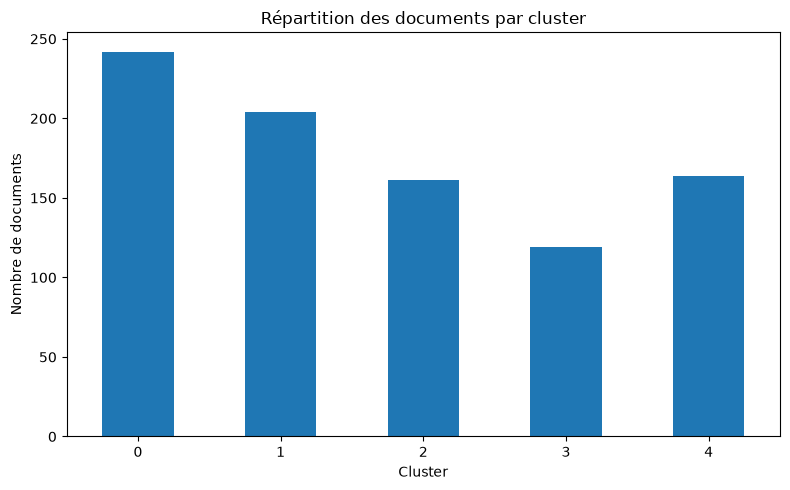

In [1512]:
import matplotlib.pyplot as plt
import pandas as pd


cluster_counts = (
    pd.Series(clusters)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Répartition des documents par cluster")
plt.xlabel("Cluster")
plt.ylabel("Nombre de documents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    figures_dir / "kmeans_repartition_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

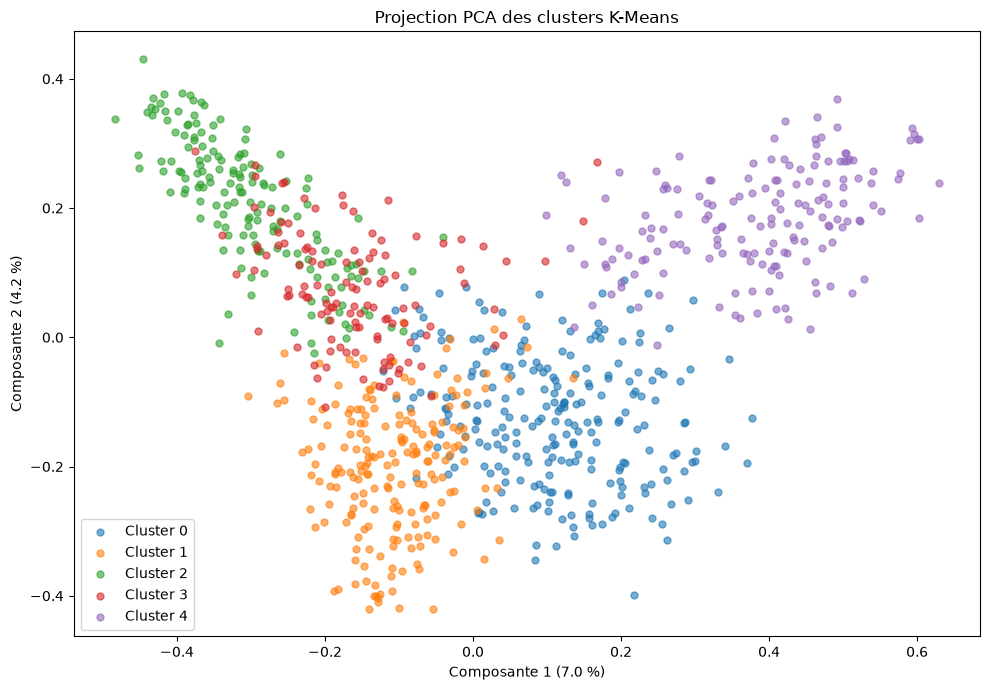

In [1513]:
from sklearn.decomposition import PCA


pca = PCA(
    n_components=2,
    random_state=42
)

coordinates = pca.fit_transform(
    tfidf_vectors.toarray()
)

plt.figure(figsize=(10, 7))

for cluster_id in range(N_CLUSTERS):
    mask = clusters == cluster_id

    plt.scatter(
        coordinates[mask, 0],
        coordinates[mask, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=25
    )

plt.title("Projection PCA des clusters K-Means")
plt.xlabel(
    f"Composante 1 ({pca.explained_variance_ratio_[0] * 100:.1f} %)"
)
plt.ylabel(
    f"Composante 2 ({pca.explained_variance_ratio_[1] * 100:.1f} %)"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "kmeans_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

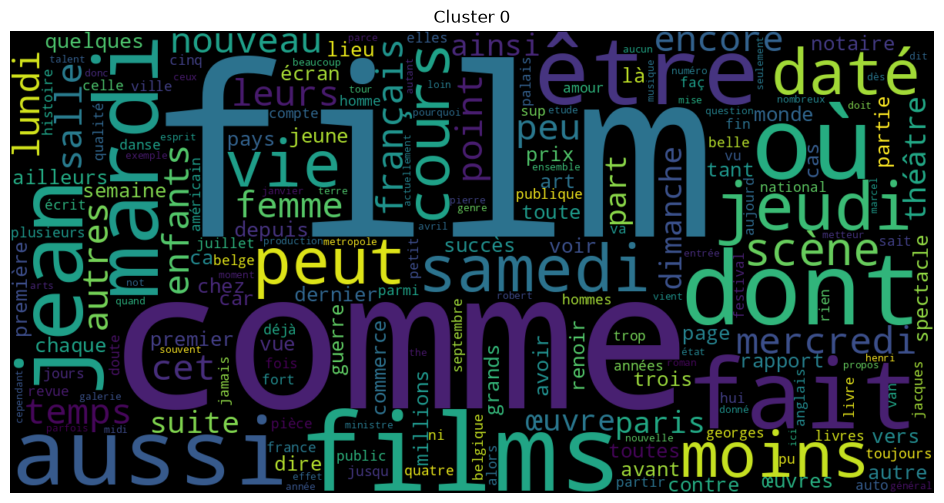

Cluster 0 : [('film', 175), ('comme', 113), ('films', 107), ('dont', 93), ('où', 93), ('fait', 85), ('être', 81), ('aussi', 78), ('jean', 74), ('mardi', 71), ('jeudi', 68), ('vie', 65), ('samedi', 65), ('peut', 64), ('moins', 63)]


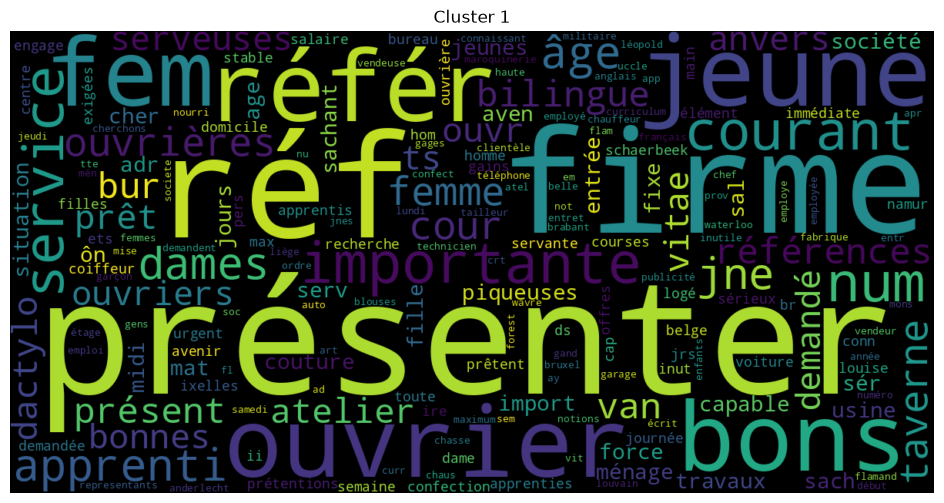

Cluster 1 : [('présenter', 143), ('firme', 113), ('réf', 113), ('jeune', 107), ('ouvrier', 106), ('référ', 106), ('bons', 102), ('fem', 97), ('importante', 91), ('service', 87), ('num', 84), ('courant', 83), ('apprenti', 82), ('âge', 81), ('dames', 77)]


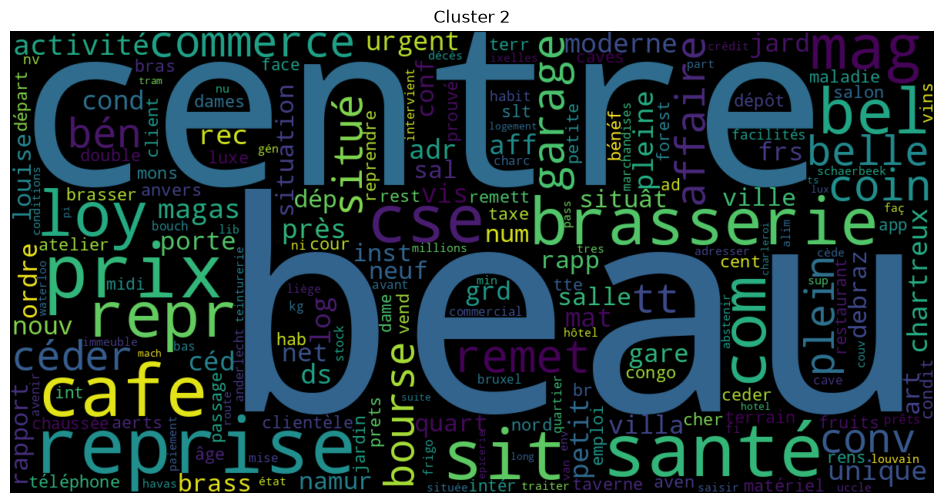

Cluster 2 : [('beau', 150), ('centre', 149), ('reprise', 144), ('prix', 136), ('santé', 132), ('cafe', 121), ('sit', 115), ('cse', 102), ('brasserie', 100), ('repr', 96), ('mag', 94), ('bel', 93), ('loy', 92), ('com', 92), ('remet', 91)]


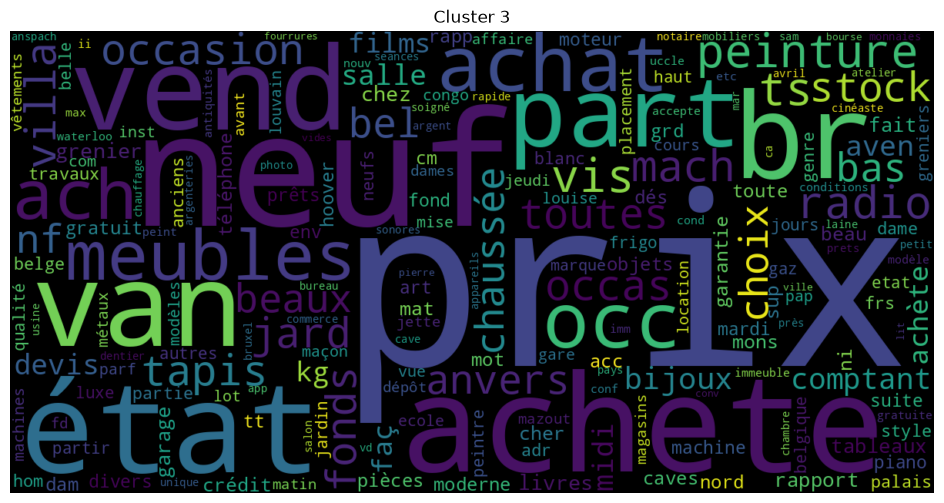

Cluster 3 : [('prix', 236), ('neuf', 80), ('achete', 55), ('état', 48), ('br', 42), ('van', 41), ('vend', 40), ('part', 39), ('achat', 37), ('occ', 36), ('meubles', 36), ('ach', 36), ('peinture', 34), ('vis', 34), ('ts', 33)]


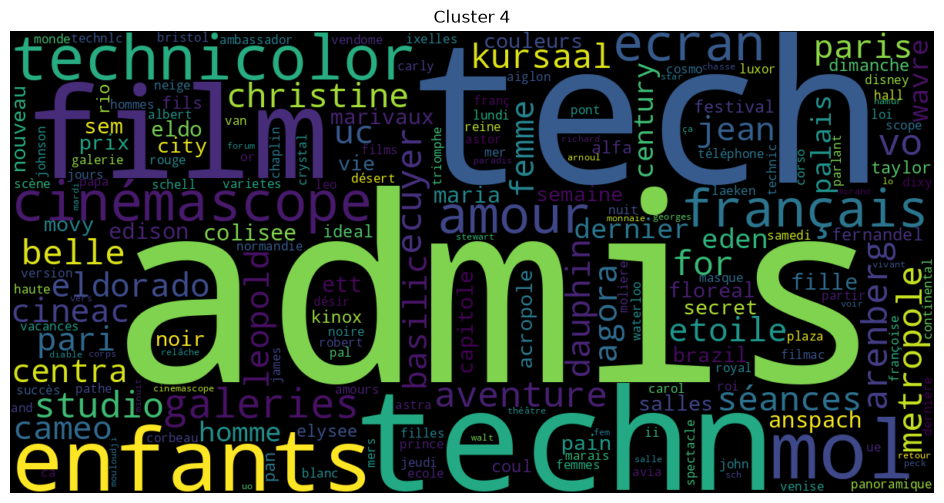

Cluster 4 : [('admis', 228), ('tech', 201), ('techn', 178), ('film', 141), ('enfants', 138), ('mol', 121), ('technicolor', 117), ('cinémascope', 109), ('français', 98), ('amour', 97), ('ecran', 95), ('galeries', 94), ('vo', 81), ('studio', 76), ('aventure', 76)]


In [1514]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from wordcloud import WordCloud


figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)


for cluster_id in range(N_CLUSTERS):

    cluster_texts = df.loc[
        df["CLUSTER"] == cluster_id,
        "TEXTE_NETTOYE"
    ]

    cluster_tokens = []

    for text in cluster_texts:
        tokens = preprocessing(text)

        cluster_tokens.extend(
            token
            for token in tokens
            if token not in stop_words
        )

    frequencies = Counter(cluster_tokens)

    wordcloud = WordCloud(
        width=1200,
        height=600,
        collocations=False
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster_id}")

    plt.savefig(
        figures_dir / f"cluster_{cluster_id}_wordcloud.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Cluster {cluster_id} :",
        frequencies.most_common(15)
    )

In [ ]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from wordcloud import WordCloud


figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)


for cluster_id in range(N_CLUSTERS):

    cluster_texts = df.loc[
        df["CLUSTER"] == cluster_id,
        "TEXTE_NETTOYE"
    ]

    cluster_tokens = []

    for text in cluster_texts:
        tokens = preprocessing(text)

        cluster_tokens.extend(
            token
            for token in tokens
            if token not in stop_words
        )

    frequencies = Counter(cluster_tokens)

    wordcloud = WordCloud(
        width=1200,
        height=600,
        collocations=False
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster_id}")

    plt.savefig(
        figures_dir / f"cluster_{cluster_id}_wordcloud.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()